### FRMEWORK FOR DEVELOPING TRADING STRACTEGY

In [1]:
# TRADING STRACTEGY FRAMEWORK;

# 1. IMPORTING DATILY DATA
# 2. CALCULATING THE PIVOT,SUPPORT AND RESISTANCE ON WEEKLY BASIS
# 3. CONFIRM THE VALUES FROM TRADING VIEW
# 4. IDENTIFYING THE BREAKOUT (EXCLUDING FALSE BREAKOUTS AND CIRCUITS, DAYS WHICH HAVE 0 TRADING)
# 5. CALCULATING THE POST-BREAKOUT PRICE MOVEMENT ANALYSIS
# 6. CREATE A TRADING STRACTEGY
# 7. BACK TESTING THE STRACTEGY

### IMPORTING REQUIRED LIBRARIES

In [2]:
# IMPORTING REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date as dt
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

/usr/local/lib/python3.10/dist-packages/yfinance/base.py:48: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  _empty_series = pd.Series()


In [3]:
# SETTING UP THE PLOTTING BACKGROUND

plt.rcParams['font.size'] = 11
plt.rc('font', family='serif')
# sns.set_style('darkgrid')
# plt.rcParams['figure.facecolor'] = '#00000000'

In [4]:
# MOUNTING THE DRIVE

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# IGNORE WARNINGS

import warnings
warnings.filterwarnings("ignore")

### IMPORTING THE DATA

In [6]:
# IMPORTING THE LIST OF EQUITIES IN NSE

Ticker_df = pd.read_excel('/content/drive/MyDrive/WQU_Capstone/MCAP31032023_0.xlsx')
Ticker_df.head()

,Sr. No.,Symbol,Company Name,"Market capitalization as on March 31, 2023\n(Rs in Lakhs)"
0,1,RELIANCE,Reliance Industries Limited,157706937.768198
1,2,TCS,Tata Consultancy Services Limited,117305527.967007
2,3,HDFCBANK,HDFC Bank Limited,89808750.012063
3,4,ICICIBANK,ICICI Bank Limited,61248250.447697
4,5,HINDUNILVR,Hindustan Unilever Limited,60157759.876617


In [7]:
# TOP 100 COMPANIES CONSIDERD

list(Ticker_df['Company Name'][:20])

['Reliance Industries Limited',
 'Tata Consultancy Services Limited',
 'HDFC Bank Limited',
 'ICICI Bank Limited',
 'Hindustan Unilever Limited',
 'Infosys Limited',
 'Housing Development Finance Corporation Limited',
 'ITC Limited',
 'State Bank of India',
 'Bharti Airtel Limited',
 'Kotak Mahindra Bank Limited',
 'Bajaj Finance Limited',
 'Life Insurance Corporation Of India',
 'Larsen & Toubro Limited',
 'HCL Technologies Limited',
 'Asian Paints Limited',
 'Axis Bank Limited',
 'Maruti Suzuki India Limited',
 'Sun Pharmaceutical Industries Limited',
 'Titan Company Limited']

In [8]:
# CONSIDERING TOP 100 STOCKS FROM NIFTY

# THE DATA FOR 'Housing Development Finance Corporation Limited',IS NOT FOUND, SO CONSIDERING 101 STOCKS

Top_100 = list(Ticker_df['Symbol'][:101])
print(Top_100)

['RELIANCE', 'TCS', 'HDFCBANK', 'ICICIBANK', 'HINDUNILVR', 'INFY', 'HDFC', 'ITC', 'SBIN', 'BHARTIARTL', 'KOTAKBANK', 'BAJFINANCE', 'LICI', 'LT', 'HCLTECH', 'ASIANPAINT', 'AXISBANK', 'MARUTI', 'SUNPHARMA', 'TITAN', 'DMART', 'ULTRACEMCO', 'BAJAJFINSV', 'WIPRO', 'ADANIENT', 'ONGC', 'NTPC', 'JSWSTEEL', 'POWERGRID', 'M&M', 'LTIM', 'TATAMOTORS', 'ADANIGREEN', 'ADANIPORTS', 'COALINDIA', 'TATASTEEL', 'HINDZINC', 'PIDILITIND', 'SIEMENS', 'ADANITRANS', 'SBILIFE', 'IOC', 'BAJAJ-AUTO', 'GRASIM', 'TECHM', 'HDFCLIFE', 'BRITANNIA', 'VEDL', 'GODREJCP', 'DABUR', 'ATGL', 'SHREECEM', 'HAL', 'HINDALCO', 'VBL', 'DLF', 'BANKBARODA', 'INDUSINDBK', 'EICHERMOT', 'DRREDDY', 'DIVISLAB', 'BPCL', 'HAVELLS', 'ADANIPOWER', 'INDIGO', 'CIPLA', 'AMBUJACEM', 'SRF', 'ABB', 'BEL', 'SBICARD', 'GAIL', 'BAJAJHLDNG', 'TATACONSUM', 'ICICIPRULI', 'CHOLAFIN', 'MARICO', 'APOLLOHOSP', 'TATAPOWER', 'BOSCHLTD', 'BERGEPAINT', 'JINDALSTEL', 'MCDOWELL-N', 'UPL', 'AWL', 'ICICIGI', 'TORNTPHARM', 'CANBK', 'PNB', 'TVSMOTOR', 'ZYDUSLIFE', '

In [9]:
# FORMATTING THE TICKER

Top_100_updated = [ticker + ".NS" for ticker in Top_100]

In [10]:
# DOWNLOADING 1 DAY DATA FOR 100 STOCKS

day_list = []
for i in Top_100_updated:
  current_price = yf.download(i, start="2022-12-31", end="2023-09-01",interval="1d", rounding=True)
  current_price["Symbol"] = i
  day_list.append(current_price)

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['HDFC.NS']: Exception('%ticker%: No price data found, symbol may be delisted (1d 2022-12-31 -> 2023-09-01)')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[***********

In [11]:
# COMBINING THE DATAFRAME FOR 100 STOCKS

day_df = pd.concat(day_list)
day_df  = day_df .reset_index()
day_df_new = day_df[day_df.isna().any(axis=1) == False]
day_df_new.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume,Symbol
0,2023-01-02,2550.00,2579.00,2548.20,2575.90,2566.83,2453414.0,RELIANCE.NS
1,2023-01-03,2565.05,2573.00,2547.80,2557.05,2548.05,3534596.0,RELIANCE.NS
2,2023-01-04,2557.00,2561.05,2514.00,2518.55,2509.68,4275746.0,RELIANCE.NS
3,2023-01-05,2523.50,2536.40,2504.00,2514.05,2505.20,6293519.0,RELIANCE.NS
4,2023-01-06,2526.65,2547.95,2518.30,2536.90,2527.97,2930338.0,RELIANCE.NS
5,2023-01-09,2545.30,2602.00,2543.35,2596.80,2587.66,4948549.0,RELIANCE.NS
6,2023-01-10,2606.00,2606.00,2546.00,2558.40,2549.39,3713755.0,RELIANCE.NS
7,2023-01-11,2552.50,2558.00,2521.10,2526.15,2517.26,5311657.0,RELIANCE.NS
8,2023-01-12,2524.85,2532.50,2465.00,2471.60,2462.90,8163366.0,RELIANCE.NS
9,2023-01-13,2458.40,2472.90,2434.60,2467.60,2458.91,9515473.0,RELIANCE.NS


In [12]:
# GENERAL FUNCTION TO CREATE A WEEK VARIABLE
def create_week (df):
  df['Week'] = df['Date'] - pd.to_timedelta(df['Date'].dt.dayofweek, unit='D')
  df['Week'] = df['Week'].dt.date
  return df

# CALLING THE FUNCTION
day_df_new = day_df_new.groupby('Symbol').apply(create_week)

### SUPPORT, PP AND RESISTANCE CALCULATION

In [13]:
# CALCULATING THE SUPPORT, PP AND RESISTANCE

def find_support_resistance (df):
  df['PP'] = (df['High'].max() + df['Low'].min() + df.iloc[-1]['Close'])/3
  df['R1'] = (df['PP']*2)-df['Low'].min()
  df['S1'] = (df['PP']*2)-df['High'].max()
  df['R2'] = df['PP'] + (df['High'].max()- df['Low'].min())
  df['S2'] = df['PP'] - (df['High'].max()- df['Low'].min())
  df['R3'] = (df['PP']*2) + (df['High'].max()- (2* df['Low'].min()))
  df['S3'] = (df['PP']*2) + ((2* df['High'].max())- df['Low'].min())

# CALCULATING WEEKLY HIGH, LOW AND CLOSE
  df['Week_low'] = df['Low'].min()
  df['Week_high'] = df['High'].max()
  df['Week_close'] = df.iloc[-1]['Close']

  return df

In [14]:
# CALLING THE FUNCTION

Support_Resistance_df_1 = day_df_new.groupby(['Symbol','Week']).apply(find_support_resistance)

In [15]:
# UPDATING THE WEEK FORMAT

Support_Resistance_df_1['Week'] = pd.to_datetime(Support_Resistance_df_1['Week']).dt.date

In [16]:
Support_Resistance_df_1.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Symbol,Week,PP,R1,S1,R2,S2,R3,S3,Week_low,Week_high,Week_close
0,2023-01-02,2550.00,2579.00,2548.2,2575.90,2566.83,2453414.0,RELIANCE.NS,2023-01-02,2539.966667,2575.933333,2500.933333,2614.966667,2464.966667,2650.933333,7733.933333,2504.0,2579.0,2536.9
1,2023-01-03,2565.05,2573.00,2547.8,2557.05,2548.05,3534596.0,RELIANCE.NS,2023-01-02,2539.966667,2575.933333,2500.933333,2614.966667,2464.966667,2650.933333,7733.933333,2504.0,2579.0,2536.9
2,2023-01-04,2557.00,2561.05,2514.0,2518.55,2509.68,4275746.0,RELIANCE.NS,2023-01-02,2539.966667,2575.933333,2500.933333,2614.966667,2464.966667,2650.933333,7733.933333,2504.0,2579.0,2536.9
3,2023-01-05,2523.50,2536.40,2504.0,2514.05,2505.20,6293519.0,RELIANCE.NS,2023-01-02,2539.966667,2575.933333,2500.933333,2614.966667,2464.966667,2650.933333,7733.933333,2504.0,2579.0,2536.9
4,2023-01-06,2526.65,2547.95,2518.3,2536.90,2527.97,2930338.0,RELIANCE.NS,2023-01-02,2539.966667,2575.933333,2500.933333,2614.966667,2464.966667,2650.933333,7733.933333,2504.0,2579.0,2536.9


In [17]:
Support_Resistance_df_1[Support_Resistance_df_1.Symbol == 'HDFCBANK.NS'].head()

,Date,Open,High,Low,Close,Adj Close,Volume,Symbol,Week,PP,R1,S1,R2,S2,R3,S3,Week_low,Week_high,Week_close
330,2023-01-02,1627.0,1639.75,1618.55,1628.70,1610.23,2190689.0,HDFCBANK.NS,2023-01-02,1606.116667,1634.033333,1566.483333,1673.666667,1538.566667,1701.583333,4925.533333,1578.2,1645.75,1594.4
331,2023-01-03,1622.2,1643.00,1622.20,1639.35,1620.76,4189015.0,HDFCBANK.NS,2023-01-02,1606.116667,1634.033333,1566.483333,1673.666667,1538.566667,1701.583333,4925.533333,1578.2,1645.75,1594.4
332,2023-01-04,1635.0,1645.75,1607.00,1610.05,1591.80,5175800.0,HDFCBANK.NS,2023-01-02,1606.116667,1634.033333,1566.483333,1673.666667,1538.566667,1701.583333,4925.533333,1578.2,1645.75,1594.4
333,2023-01-05,1615.0,1618.05,1589.40,1599.70,1581.56,5470718.0,HDFCBANK.NS,2023-01-02,1606.116667,1634.033333,1566.483333,1673.666667,1538.566667,1701.583333,4925.533333,1578.2,1645.75,1594.4
334,2023-01-06,1602.0,1609.10,1578.20,1594.40,1576.32,4546231.0,HDFCBANK.NS,2023-01-02,1606.116667,1634.033333,1566.483333,1673.666667,1538.566667,1701.583333,4925.533333,1578.2,1645.75,1594.4


In [18]:
# UPDATING SUPPORT, RESISTANCE AND PIVOT
    # For  a particular hourly candle, the support, pp and resistance from previous week

list_df = []
for i in Top_100_updated:
  df = Support_Resistance_df_1[Support_Resistance_df_1.Symbol == i]
  prior_value = df.groupby('Week')[['PP','R1','S1','R2','S2','R3','S3']].mean().shift(1)
  merged = df.merge(prior_value, on='Week', suffixes=('', 'prior_value'))
  merged = merged.drop(['PP','R1','S1','R2','S2','R3','S3'],axis = 1)
  cols = {'PPprior_value':'PP','R1prior_value':'R1','S1prior_value':'S1','R2prior_value':'R2','S2prior_value':'S2',
          'R3prior_value':'R3','S3prior_value':'S3'}
  merged.rename(columns=cols, inplace=True)
  list_df.append(merged)

In [19]:
# COMBINING THE RESULTS

combined_df = pd.concat(list_df, ignore_index=True)

### PLOTTING THE GRAPH

In [20]:
# # PLOTTING RESULTS FOR TOP 10 STOCKS

for i in Top_100_updated[:10]:
    # Creating the dataframe
    check_stock = combined_df[combined_df.Symbol == i]

    # Plotting the graph
    fig = go.Figure(data=[go.Candlestick(x=check_stock.Date,
                                        open=check_stock.Open,
                                        high=check_stock.High,
                                        low=check_stock.Low,
                                        close=check_stock.Close,
                                        name=i)])

    fig.update_layout(title=f"Candlestick Chart for {i}",  # Add stock name to the title
                      xaxis_rangeslider_visible=False)

    fig.add_trace(go.Scatter(
        x=check_stock.Date,
        y=check_stock.PP,
        marker=dict(color="black", size=2),
        mode="markers",
        name="PP"
    ))

    fig.add_trace(go.Scatter(
        x=check_stock.Date,
        y=check_stock.S1,
        marker=dict(color="orange", size=2),
        mode="markers",
        name="S1"
    ))
    fig.add_trace(go.Scatter(
        x=check_stock.Date,
        y=check_stock.R1,
        marker=dict(color="green", size=2),
        mode="markers",
        name="R1"
    ))

    # Add arrow markers where the price is above R1
    above_r1 = check_stock[check_stock['Close'] > check_stock['R1']]
    for _, row in above_r1.iterrows():
        fig.add_shape(
            dict(
                type="line",
                x0=row['Date'],
                x1=row['Date'],
                y0=row['R1'],
                y1=row['R1'] + 10,  # Adjust the arrow length as needed
                line=dict(color="blue", width=2),
                )
        )

    fig.update_layout(
        xaxis=dict(
            tickangle=-90
        ),
        width=1500,
        height=700
    )

    fig.show()


In [21]:
# CREATING NEW VARIABLE FOR CANDLE COLOUR

combined_df['Candle_Color'] = ['Red' if close > open else 'Green' for open, close in zip(combined_df['Open'], combined_df['Close'])]

In [22]:
# CREATING NEW VARIABLES

def previous_next_close(df):

  df['Previous_close'] = df['Close'].shift(1)
  df['Next_close_1'] = df['Close'].shift(-1)
  df['Next_close_2'] = df['Close'].shift(-2)
  df['Next_close_3'] = df['Close'].shift(-3)
  df['Next_close_4'] = df['Close'].shift(-4)

# SIZE OF THE CANDLE
  df['Candle_Size'] = df['Close']-df['Open']

  return df


# CALLING THE FUNCTION
combined_df_1 = combined_df.groupby('Symbol').apply(previous_next_close)

### BREAKOUT IDENTIFICATION

In [23]:
def identify_r1_breakout(data):
    breakout_flag = False
    breakout_candle = []

    for index, row in data.iterrows():
        if index == 0:
            continue

        prev_close = data.at[index - 1, 'Close']
        current_close = row['Close']
        r1 = row['R1']
        r2 = row['R2']
        candle_size = row['Candle_Size']
       # candle_colour = row['Candle_Color']

        # Check if the conditions for an R1 breakout are met
        if (current_close > r1) and (prev_close < r1) and ((candle_size * 0.5 + row['Open']) > r1) and (candle_size >= 1):
            # Additional condition: Check if the next close is less than R2 and greater than close of current close
            next_index = index + 1
            next_index_2 = index + 2
            next_index_3 = index + 3
            next_index_4 = index + 4

            if next_index < len(data):
                next_close = data.at[next_index, 'Close']
                next_close_2 = data.at[next_index_2, 'Close']
                next_close_3 = data.at[next_index_3, 'Close']
                next_close_4 = data.at[next_index_4, 'Close']

                if (next_close > r1) and (next_close_2 > r1) and (next_close_3 > r1) and (next_close_4 >r1):
                    if not breakout_flag:
                        breakout_flag = True
                        breakout_candle.append(True)
                    else:
                        breakout_candle.append(False)
                else:
                    breakout_flag = False
                    breakout_candle.append(False)
            else:
                breakout_flag = False
                breakout_candle.append(False)
        else:
            breakout_flag = False
            breakout_candle.append(False)

    breakout_candle.insert(0, False)
    data['Breakout_R1'] = breakout_candle

    return data

breakout = identify_r1_breakout(combined_df_1)

### ANALYSING R1 BREAKOUT DATA

In [24]:
# TOTAL BREAKOUTS/BREAKDOWN CANDLES FOR ALL STOCKS

print(f"The number of breakout candles are :  {breakout[breakout.Breakout_R1 == True].shape[0]}")

The number of breakout candles are :  336


In [25]:
# TOTAL NUMBER OF CANDLES THAT ARE NOT BREAKOUT/BREAKDOWN CANDLES

print(f"The number of non breakout candles are : {breakout[breakout.Breakout_R1 == False].shape[0]}")

The number of non breakout candles are : 15996


In [26]:
# NUMBER OF BREAKOUTS IDENTIFIED IN CIRCUITS

breakout[(breakout.Breakout_R1 == True) & (breakout.High== breakout.Open) ].shape

(0, 27)

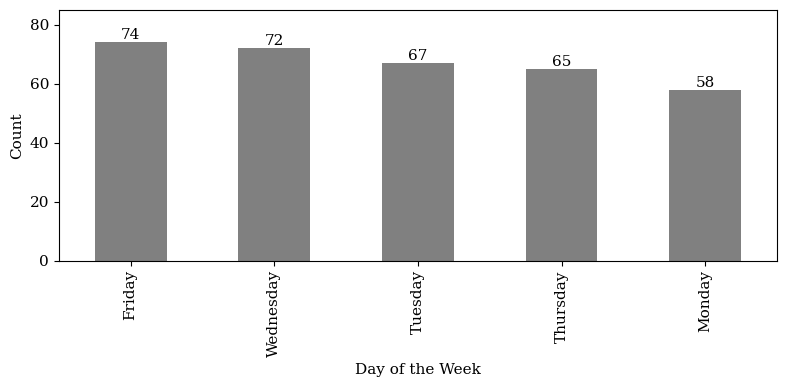

In [27]:
# IDENTIFYING THE BREAKOUT PER DAYS

R1_breakout_data = breakout[breakout.Breakout_R1 == True]
R1_breakout_data['day_of_week'] = R1_breakout_data['Date'].dt.dayofweek
R1_breakout_data['day_of_week'] =R1_breakout_data['day_of_week'].map({
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
})

day_counts = R1_breakout_data['day_of_week'].value_counts()

# Create a bar chart
import matplotlib.pyplot as plt
plt.rc('font', family='serif')
plt.figure(figsize=(8, 4))
ax = day_counts.plot(kind='bar', color='gray')

# Adding labels inside the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points',
                color='black')

#plt.title('Breakout Occurrences by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
plt.ylim(0, 85)
plt.tight_layout()
plt.show()


### CHECKING BREAKOUTS FOR FEW STOCKS

In [28]:
# CHECKING THE BREAKOUT POINTS FOR A PARTICULAR STOCKS

def check_breakout_for_stocks(breakout,i):

  # SHOWING ONLY TOP 15 OBSERVATIONS
  Check_df = breakout[(breakout.Breakout_R1 == True ) & (breakout.Symbol == i)][['Date','High','Low','Open','Close','PP','R1','S1','R2','S2']]

  # PRINTING THE TOTAL NUMBER OF BREAKOUTS
  print(f'The total number of breakouts for {i} is:',Check_df.shape[0])
  return Check_df

In [29]:
# IDENTIFIED BREAKOUTS FOR HDFCBANK

check_breakout_for_stocks(breakout,'HDFCBANK.NS')

The total number of breakouts for HDFCBANK.NS is: 3


,Date,High,Low,Open,Close,PP,R1,S1,R2,S2
390,2023-03-29,1602.00,1581.9,1584.0,1587.80,1565.466667,1585.533333,1540.583333,1610.416667,1520.516667
393,2023-04-05,1656.00,1616.0,1618.6,1653.75,1593.800000,1628.700000,1574.650000,1647.850000,1539.750000
445,2023-06-21,1637.25,1611.0,1616.0,1635.60,1599.183333,1619.366667,1582.566667,1635.983333,1562.383333


In [30]:
# IDENTIFIED BREAKOUTS FOR ICICBANK

check_breakout_for_stocks(breakout,'ICICBANK.NS')

The total number of breakouts for ICICBANK.NS is: 0


,Date,High,Low,Open,Close,PP,R1,S1,R2,S2


In [31]:
# IDENTIFIED BREAKOUTS FOR TCS

check_breakout_for_stocks(breakout,'TCS.NS')

The total number of breakouts for TCS.NS is: 4


,Date,High,Low,Open,Close,PP,R1,S1,R2,S2
172,2023-01-11,3349.50,3271.15,3290.10,3328.70,3249.616667,3299.233333,3161.933333,3386.916667,3112.316667
226,2023-03-31,3213.00,3152.00,3189.95,3205.90,3128.516667,3161.983333,3087.033333,3203.466667,3053.566667
296,2023-07-14,3524.85,3352.00,3365.00,3514.65,3318.300000,3367.850000,3279.700000,3406.450000,3230.150000
311,2023-08-04,3471.00,3401.25,3401.25,3443.55,3369.083333,3407.166667,3317.316667,3458.933333,3279.233333


In [32]:
# IDENTIFIED BREAKOUTS FOR HINDUNILVR

check_breakout_for_stocks(breakout,'HINDUNILVR.NS')

The total number of breakouts for HINDUNILVR.NS is: 2


,Date,High,Low,Open,Close,PP,R1,S1,R2,S2
746,2023-05-11,2599.00,2523.6,2536.95,2592.4,2490.250000,2530.500000,2460.500000,2560.250000,2420.250000
761,2023-06-01,2731.25,2654.5,2667.00,2697.9,2629.866667,2679.183333,2603.033333,2706.016667,2553.716667


In [33]:
# IDENTIFIED BREAKOUTS FOR INFY

check_breakout_for_stocks(breakout,'INFY.NS')

The total number of breakouts for INFY.NS is: 4


,Date,High,Low,Open,Close,PP,R1,S1,R2,S2
847,2023-02-02,1586.95,1552.00,1552.00,1583.75,1531.783333,1556.166667,1494.766667,1593.183333,1470.383333
886,2023-03-31,1429.95,1393.90,1404.00,1427.95,1390.116667,1410.233333,1360.533333,1439.816667,1340.416667
918,2023-05-22,1295.60,1270.25,1272.95,1292.80,1261.766667,1281.083333,1249.583333,1293.266667,1230.266667
946,2023-06-30,1338.90,1304.45,1308.20,1335.50,1277.783333,1292.216667,1250.566667,1319.433333,1236.133333


In [34]:
# IDENTIFIED BREAKOUTS FOR ITC

check_breakout_for_stocks(breakout,'ITC.NS')

The total number of breakouts for ITC.NS is: 6


,Date,High,Low,Open,Close,PP,R1,S1,R2,S2
1006,2023-01-24,340.75,337.60,337.80,338.95,332.900000,338.250000,329.250000,341.900000,323.900000
1056,2023-04-11,398.10,388.00,388.55,396.00,385.383333,392.266667,380.466667,397.183333,373.583333
1063,2023-04-21,409.00,399.05,400.30,408.25,392.816667,400.883333,387.533333,406.166667,379.466667
1067,2023-04-27,417.40,411.00,412.20,416.00,403.383333,413.866667,397.766667,419.483333,387.283333
1101,2023-06-15,448.75,444.75,445.00,448.10,440.150000,445.150000,433.450000,451.850000,428.450000
1112,2023-07-03,465.95,450.05,451.60,463.25,448.900000,454.650000,445.850000,457.700000,440.100000


In [35]:
updated_breakout = breakout[['Date','Symbol','High','Low','Open','Close','PP','R1','S1','R2','S2','Breakout_R1']]

# Saving the File in CSV
updated_breakout.to_csv('/content/drive/MyDrive/WQU_Capstone/Breakout_data.csv', index=False)

### PRICE MOVEMENT ANALYSIS

In [36]:
breakout.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Symbol,Week,Week_low,...,R3,S3,Candle_Color,Previous_close,Next_close_1,Next_close_2,Next_close_3,Next_close_4,Candle_Size,Breakout_R1
0,2023-01-02,2550.00,2579.00,2548.2,2575.90,2566.83,2453414.0,RELIANCE.NS,2023-01-02,2504.0,...,NaN,NaN,Red,NaN,2557.05,2518.55,2514.05,2536.90,25.90,False
1,2023-01-03,2565.05,2573.00,2547.8,2557.05,2548.05,3534596.0,RELIANCE.NS,2023-01-02,2504.0,...,NaN,NaN,Green,2575.90,2518.55,2514.05,2536.90,2596.80,-8.00,False
2,2023-01-04,2557.00,2561.05,2514.0,2518.55,2509.68,4275746.0,RELIANCE.NS,2023-01-02,2504.0,...,NaN,NaN,Green,2557.05,2514.05,2536.90,2596.80,2558.40,-38.45,False
3,2023-01-05,2523.50,2536.40,2504.0,2514.05,2505.20,6293519.0,RELIANCE.NS,2023-01-02,2504.0,...,NaN,NaN,Green,2518.55,2536.90,2596.80,2558.40,2526.15,-9.45,False
4,2023-01-06,2526.65,2547.95,2518.3,2536.90,2527.97,2930338.0,RELIANCE.NS,2023-01-02,2504.0,...,NaN,NaN,Red,2514.05,2596.80,2558.40,2526.15,2471.60,10.25,False


In [37]:
# A GENERAL FUNCTION TO FIND THE TREND IN PRICE MOVEMENT AFTER 2, 4, 5, 6, 7 HOURS

def identifty_price_trends(data):

  data['20day_avg_movement'] = data['Close'].shift(-4).rolling(window=20, min_periods=1).mean().shift(-20)
  data['25day_avg_movement'] = data['Close'].shift(-4).rolling(window=25, min_periods=1).mean().shift(-25)
  data['30day_avg_movement'] = data['Close'].shift(-4).rolling(window=30, min_periods=1).mean().shift(-30)
  data['35day_avg_movement'] = data['Close'].shift(-4).rolling(window=35, min_periods=1).mean().shift(-35)
  data['40day_avg_movement'] = data['Close'].shift(-4).rolling(window=40, min_periods=1).mean().shift(-40)

  data['20day_%_movement'] = ((data['20day_avg_movement']-data['Next_close_4'])/data['Next_close_4'])*100
  data['25day_%_movement'] = ((data['25day_avg_movement']-data['Next_close_4'])/data['Next_close_4'])*100
  data['30day_%_movement'] = ((data['30day_avg_movement']-data['Next_close_4'])/data['Next_close_4'])*100
  data['35day_%_movement'] = ((data['35day_avg_movement']-data['Next_close_4'])/data['Next_close_4'])*100
  data['40day_%_movement'] = ((data['40day_avg_movement']-data['Next_close_4'])/data['Next_close_4'])*100

  return data



# CALLING THE FUNCTION
breakout = breakout.groupby('Symbol').apply(identifty_price_trends)

#breakout.to_csv('/content/drive/MyDrive/WQU_Capstone/full_breakout_info.csv', index=False)

In [38]:
breakout.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Symbol',
       'Week', 'Week_low', 'Week_high', 'Week_close', 'PP', 'R1', 'S1', 'R2',
       'S2', 'R3', 'S3', 'Candle_Color', 'Previous_close', 'Next_close_1',
       'Next_close_2', 'Next_close_3', 'Next_close_4', 'Candle_Size',
       'Breakout_R1', '20day_avg_movement', '25day_avg_movement',
       '30day_avg_movement', '35day_avg_movement', '40day_avg_movement',
       '20day_%_movement', '25day_%_movement', '30day_%_movement',
       '35day_%_movement', '40day_%_movement'],
      dtype='object')

In [39]:
Net_price_movement = breakout[breakout.Breakout_R1 == True][['Date','Symbol','Week','Close','Next_close_4','20day_avg_movement','25day_avg_movement','30day_avg_movement',
                                                             '35day_avg_movement','40day_avg_movement']]
Net_price_movement.head()

,Date,Symbol,Week,Close,Next_close_4,20day_avg_movement,25day_avg_movement,30day_avg_movement,35day_avg_movement,40day_avg_movement
61,2023-03-31,RELIANCE.NS,2023-03-27,2331.05,2324.85,2394.3000,2409.320,2415.293333,2426.162857,2432.222500
122,2023-07-03,RELIANCE.NS,2023-07-03,2615.70,2633.60,2621.6500,2602.972,2594.716667,2579.285714,2566.326316
127,2023-07-10,RELIANCE.NS,2023-07-10,2735.05,2740.70,2566.1550,2563.612,2550.793333,2538.460606,NaN
172,2023-01-11,TCS.NS,2023-01-09,3328.70,3378.40,3449.7875,3455.792,3441.315000,3428.632857,3405.348750
226,2023-03-31,TCS.NS,2023-03-27,3205.90,3263.40,3194.8650,3207.026,3216.581667,3229.882857,3236.790000


In [40]:
Net_price_movement = breakout[breakout.Breakout_R1 == True][['Date','Symbol','Week','Close','Next_close_4','20day_avg_movement','25day_avg_movement','30day_avg_movement',
                                                             '35day_avg_movement','40day_avg_movement','20day_%_movement','25day_%_movement','30day_%_movement',
                                                             '35day_%_movement','40day_%_movement']]
Net_price_movement.head()

,Date,Symbol,Week,Close,Next_close_4,20day_avg_movement,25day_avg_movement,30day_avg_movement,35day_avg_movement,40day_avg_movement,20day_%_movement,25day_%_movement,30day_%_movement,35day_%_movement,40day_%_movement
61,2023-03-31,RELIANCE.NS,2023-03-27,2331.05,2324.85,2394.3000,2409.320,2415.293333,2426.162857,2432.222500,2.987290,3.633353,3.890287,4.357823,4.618470
122,2023-07-03,RELIANCE.NS,2023-07-03,2615.70,2633.60,2621.6500,2602.972,2594.716667,2579.285714,2566.326316,-0.453752,-1.162971,-1.476433,-2.062359,-2.554438
127,2023-07-10,RELIANCE.NS,2023-07-10,2735.05,2740.70,2566.1550,2563.612,2550.793333,2538.460606,NaN,-6.368628,-6.461415,-6.929130,-7.379115,NaN
172,2023-01-11,TCS.NS,2023-01-09,3328.70,3378.40,3449.7875,3455.792,3441.315000,3428.632857,3405.348750,2.113056,2.290789,1.862272,1.486883,0.797678
226,2023-03-31,TCS.NS,2023-03-27,3205.90,3263.40,3194.8650,3207.026,3216.581667,3229.882857,3236.790000,-2.100110,-1.727462,-1.434649,-1.027062,-0.815407


In [41]:
Net_price_movement .shape

(336, 15)

In [42]:
Net_price_movement_1 = Net_price_movement[['Date','Symbol','Week','Close','Next_close_4','20day_avg_movement','25day_avg_movement','30day_avg_movement',
                                                             '35day_avg_movement','40day_avg_movement']]

In [43]:
# SAVING THE PRICE MOVEMENT ANALYSIS IN CSV FORM :
#Net_price_movement_1.to_csv('/content/drive/MyDrive/WQU_Capstone/Net_price_movement_data.csv', index=False)

In [44]:
# GENERAL CODE FOR PRICE MOVEMENT ANALYSIS

def price_movement(data, day):

    # UPDATING THE DATAFRAME
    data = data[['Symbol','Next_close_4','{}day_avg_movement'.format(day),'{}day_%_movement'.format(day)]]
    data.dropna(inplace = True)

    # INCREMENT COUNT
    Increment_count = len(data[data['Next_close_4'] <= data['{}day_avg_movement'.format(day)]])

    # DECREMENT COUNT
    Decrement_count = len(data[data['Next_close_4'] > data['{}day_avg_movement'.format(day)]])

    # INCREMENT %
    Increment_percent = (len(data[data['Next_close_4'] <= data['{}day_avg_movement'.format(day)]])) / len(data) * 100

    # DECREMENT %
    Decrement_percent = (len(data[data['Next_close_4'] > data['{}day_avg_movement'.format(day)]])) / len(data) * 100


    # AVERAGE % MOVEMENT
    Avg_movement = data['{}day_%_movement'.format(day)].mean()

    # AVERAGE % INCREMENT
    Avg_percent_increment = data[data['Next_close_4'] <= data['{}day_avg_movement'.format(day)]]['{}day_%_movement'.format(day)].mean()

    # AVERAGE % DECREMENT
    Avg_percent_decrement = data[data['Next_close_4'] > data['{}day_avg_movement'.format(day)]]['{}day_%_movement'.format(day)].mean()

    # WORST DOWNWARD MOVEMENT
    Worst_movement = data['{}day_%_movement'.format(day)].min()

    # Create a DataFrame to store the metrics
    metrics_df = pd.DataFrame({
        'Metric': ['Increment Count', 'Decrement Count', 'Increment %', 'Decrement %',
                   'Average % Movement', 'Average % Increment', 'Average % Decrement', 'Worst Downward Movement'],
        'Result': [round(Increment_count,0), round(Decrement_count,0), round(Increment_percent,2), round(Decrement_percent,2),
                   round(Avg_movement,2), round(Avg_percent_increment,2), round(Avg_percent_decrement,2), round(Worst_movement,2)]
    }).set_index('Metric')

    print(len(data))

    return metrics_df

##### 1. **NEXT 20 DAY AVERAGE PRICE MOVEMENT**

In [45]:
price_movement(Net_price_movement, '20')

318


,Result
Metric,
Increment Count,201.00
Decrement Count,117.00
Increment %,63.21
Decrement %,36.79
Average % Movement,0.81
Average % Increment,3.16
Average % Decrement,-3.22
Worst Downward Movement,-47.95


##### 2. **FIRST 25 DAY AVERAGE PRICE MOVEMENT**

In [46]:
price_movement(Net_price_movement, '25')

310


,Result
Metric,
Increment Count,199.00
Decrement Count,111.00
Increment %,64.19
Decrement %,35.81
Average % Movement,1.13
Average % Increment,3.72
Average % Decrement,-3.51
Worst Downward Movement,-53.17


#### 3. **FIRST 30 DAY AVERAGE PRICE MOVEMENT**

In [47]:
price_movement(Net_price_movement, '30')

302


,Result
Metric,
Increment Count,194.00
Decrement Count,108.00
Increment %,64.24
Decrement %,35.76
Average % Movement,1.45
Average % Increment,4.21
Average % Decrement,-3.52
Worst Downward Movement,-56.45


#### 4. **FIRST  35 DAY AVERAGE PRICE MOVEMENT**

In [48]:
price_movement(Net_price_movement, '35')

294


,Result
Metric,
Increment Count,193.00
Decrement Count,101.00
Increment %,65.65
Decrement %,34.35
Average % Movement,1.86
Average % Increment,4.72
Average % Decrement,-3.61
Worst Downward Movement,-57.79


#### 5. **FIRST 40 DAY AVERAGE PRICE MOVEMENT**

In [49]:
price_movement(Net_price_movement, '40')

287


,Result
Metric,
Increment Count,193.00
Decrement Count,94.00
Increment %,67.25
Decrement %,32.75
Average % Movement,2.19
Average % Increment,5.14
Average % Decrement,-3.86
Worst Downward Movement,-57.91


## STRACTEGY


In [50]:
# ENTRY POINT : 4TH CANDLE AFTER THE BREAKOUT
# EXIT POINT : 40TH DAY FROM THE ENTRY POINT
# STOP-LOSS : 5% BELOW THE ENTRY POINT

## BACKTESTING THE STRACTGY

In [51]:

# DEFINING THE BASIC CONDITIONS

stop_loss_percent = 0.05
Exit_day = 40
initial_investment = 25000



# PYTHON CODE FOR CREATING THE TRADING STRACTEGY
results = []

grouped = breakout.groupby('Symbol')

for symbol, group in grouped:

    # RESETTING THE INDEX
    group = group.reset_index(drop=True)

    breakout_date = []
    breakout_price = []
    stock = []
    week = []
    entry_date = []
    entry_price = []
    exit_date = []
    exit_price = []
    exit_on = []
    holding_duration = []
    stop_loss = []
    num_stocks = []

    for index, row in group.iterrows():

      # CALCULATING BREAKOUT DATE
        if row['Breakout_R1']:
            breakout_date.append(row['Date'])
            breakout_price.append(row['Close'])
            stock.append(symbol)
            week.append(row['Week'])

      # CALCULATING THE ENTRY POINT
            fourth_index = index + 4
            if fourth_index < len(group):
                entry_date.append(group.iloc[fourth_index]['Date'])
                entry_price.append(group.iloc[fourth_index]['Close'])

      # NUMBER OF STOCKS
                num_stocks_purchased = np.floor(initial_investment / entry_price[-1])
                num_stocks.append(num_stocks_purchased)

      #  STOP-LOSS
                stop_loss_price = entry_price[-1] * (1 - stop_loss_percent)

      # CALCULATING THE EXITS
                exit_date_stop_loss = None
                exit_price_stop_loss = None
                exit_date_holding_period = None
                exit_price_holding_period = None
                exit_on_stop_loss = None
                exit_on_holding_period = None

                for i in range(fourth_index, min(len(group), fourth_index + Exit_day)):
                    next_row = group.iloc[i]

                # CHECKING THE EXIT ON STOP-LOSS
                    if next_row['Close'] <= stop_loss_price and i != (fourth_index + Exit_day - 1):
                        exit_date_stop_loss = next_row['Date']
                        exit_price_stop_loss = stop_loss_price
                        exit_on_stop_loss = 'Stop Loss'
                        break

                # CHECKING THE EXIT ON HOLDING DAY
                    if i == fourth_index + Exit_day - 1:
                        exit_date_holding_period = next_row['Date']
                        exit_price_holding_period= next_row['Close']
                        exit_on_holding_period = '40th Day'

                # UPDATING THE EXIT ON
                if exit_date_holding_period is None:
                    exit_on_holding_period = "Data Not Available"

                if exit_date_stop_loss is None and exit_date_holding_period is None:
                    exit_date_holding_period = np.nan
                    exit_price_holding_period = np.nan
                    exit_on_holding_period = "Data Not Available"

                if exit_date_stop_loss and not exit_date_holding_period:
                    exit_price_holding_period = stop_loss_price

                # UPDATING THE HOLDING PERIOD
                if exit_on_holding_period != 'Data Not Available':
                    holding_period = i - fourth_index + 1
                elif exit_date_stop_loss:
                    holding_period = i - fourth_index + 1
                else:
                    holding_period = np.nan

                # SAVE THE VALUES
                trade_data = {

                    'Breakout Date': breakout_date[-1],
                    'Breakout Price': breakout_price[-1],
                    'Symbol': stock[-1],
                    'Entry Date': entry_date[-1],
                    'Entry Price': entry_price[-1],
                    'Exit Date': exit_date_stop_loss if exit_date_stop_loss else exit_date_holding_period,
                    'Exit Price': exit_price_stop_loss if exit_price_stop_loss else exit_price_holding_period,
                    'Exit On': exit_on_stop_loss if exit_on_stop_loss else exit_on_holding_period,
                    'Holding Duration': holding_period,
                    'Stop Loss': stop_loss_price,
                    'Stocks Purchased': num_stocks[-1],
                    'initial-investment': initial_investment,
                    #'Final amount': final_amount,
                    #'Profit/Loss':profit_loss
                                               }
                results.append(trade_data)


# CREATING THE DATAFRAME
df = pd.DataFrame(results)
df['Profit/Loss'] = (df['Exit Price']-df['Entry Price'])*df['Stocks Purchased']
df['Final amount'] = df['Profit/Loss'] + df['initial-investment']

# CALCULATING THE METRICS FOR EVALUATING THE PERFORMANCE OF TRADING STRACTEGY

# WINNING TRADE

# CONSIDERING THE TRADES WHICH HAVE DEFINED HOLDING PERIOD DATA
df_final = df.dropna(subset = ['Exit Date'])

# MISSING TRADES
missing_trades = df['Exit Date'].isna().sum()

# Filter winning and losing trades
winning_trades = df_final[df_final['Profit/Loss'] >= 0]
losing_trades = df_final[df_final['Profit/Loss'] < 0]

# Calculate the win-loss ratio
win_loss_ratio = len(winning_trades) / len(losing_trades)

# Total Investment
total_investment = df_final['initial-investment'].sum()

# Total return
final_return = df_final['Final amount'].sum()

# Total profit/loss
net_profit_loss = final_return-total_investment

# Average profit per trade
avg_profit_per_trade = df_final['Profit/Loss'].mean()

# Average trade duration
avg_trade_duration = df_final['Holding Duration'].mean()

# ROI
ROI = (net_profit_loss/total_investment)



# PRINITNG THE RESULTS

print("Total available trades",len(df))
print("Missing Trades:", missing_trades)
print("Winning Trades:", len(winning_trades))
print("Losing Trades:", len(losing_trades))
print("Win-Loss Ratio:", round(win_loss_ratio,2))
print("Total Investment:", total_investment)
print("Total Return:", round(final_return,0))
print("Net Profit/Loss:", round(net_profit_loss,0))
print("Average Profit per Trade:", round(avg_profit_per_trade,0))
print("Average Trade Duration:", round(avg_trade_duration,0))
print("ROI:", round(ROI,3))

Total available trades 333
Missing Trades: 36
Winning Trades: 165
Losing Trades: 132
Win-Loss Ratio: 1.25
Total Investment: 7425000
Total Return: 7665930.0
Net Profit/Loss: 240930.0
Average Profit per Trade: 811.0
Average Trade Duration: 31.0
ROI: 0.032


In [52]:
# 3 trades doesn't have the 4 th day candle data (Total available trades mentioned above excludes these three trades)

In [53]:
# SAVING THE FILE
#df_final.to_csv('/content/drive/MyDrive/WQU_Capstone/Trading_final_results.csv')

In [54]:
# PER DAY TOTAL PROFIT/LOSS CALCULATION

Symbol = []
breakout_date = []
entry_date = []
exit_date = []
daily_price_changes = []

# TRADING STRACTEGY CONDITIONS

stop_loss_percent = 0.05
Exit_day = 40
initial_investment = 25000

# PYTHON CODE FOR THE TRADING STRACTEGY
for symbol, group in breakout.groupby('Symbol'):
    group = group.reset_index(drop=True)
    for index, row in group.iterrows():
        if row['Breakout_R1']:
            breakout_date.append(row['Date'])
            Symbol.append(row['Symbol'])
            fourth_index = index + 4
            if fourth_index < len(group):
                entry_date.append(group.iloc[fourth_index]['Date'])
                entry_price = group.iloc[fourth_index]['Close']
                stop_loss_price = entry_price * (1 - stop_loss_percent)
                stock = np.floor(initial_investment/entry_price)
                exit_date_stop_loss = None
                exit_date_40th_day = None
                daily_price_changes_trade = [np.nan] * Exit_day

                for i in range(fourth_index, min(len(group), fourth_index + Exit_day)):
                    next_row = group.iloc[i]
                    previous_row = group.iloc[i-1]

                    if next_row['Close'] <= stop_loss_price and i != (fourth_index + Exit_day - 1):
                        exit_date_stop_loss = next_row['Date']
                        break

                    if i == fourth_index + Exit_day - 1:
                        exit_date_40th_day = next_row['Date']

                    if i >= fourth_index:
                        day_index = i - fourth_index
                        #  print(day_index)
                        #daily_price_changes_trade[day_index] = (next_row['Close'] - entry_price)
                        daily_price_changes_trade[day_index] = (next_row['Close'] - previous_row['Close'])*stock
                exit_date.append(exit_date_stop_loss if exit_date_stop_loss else exit_date_40th_day)
                daily_price_changes.append(daily_price_changes_trade)

            else:
                entry_date.append(None)
                exit_date.append(None)
                daily_price_changes.append([np.nan] * Exit_day)

data = {
    'Symbol':Symbol,
    'Date': breakout_date,
    'Breakout Date': breakout_date,
    'Entry Date': entry_date,
    'Exit Date': exit_date
}

#print(data)

# DAILY PRICE CHNAGE CALCULATION
for day in range(1, Exit_day + 1):
    if day == 1:
        data[f'Day {day} Price Change'] = [0] * len(Symbol)
    else:
        data[f'Day {day} Price Change'] = [price_changes[day - 1] if not np.isnan(price_changes[day - 1]) and exit and entry else np.nan for price_changes, exit, entry in zip(daily_price_changes, exit_date, entry_date)]


# DATAFRAME FOR PRICE CHANAGE
df_price_change = pd.DataFrame(data)
df_Day_total = df_price_change.copy()


# CALCULATING THE TOTAL AMOUNT PER DAY
price_change_columns = [f'Day {day} Price Change' for day in range(1, (Exit_day+1))]
total_amount = initial_investment
for day in range(1, (Exit_day+1)):
    total_amount += df_Day_total[f'Day {day} Price Change']
    df_Day_total[f'Day {day} Total Amount'] = total_amount
df_total = df_Day_total.drop(price_change_columns, axis=1)


# DATA FRAME ONLY WITH THE TRADES WHICH HAVE FULL DATA FOR THE HOLDING PERIOD
df_final_updated = df_total.dropna(subset=['Exit Date'])

In [55]:
#df_final_updated.to_csv('/content/drive/MyDrive/WQU_Capstone/Trading_results_per_day.csv')

In [56]:
# MERGING THE TWO RESULT DATAFRAMES

merge_columns = ['Symbol', 'Entry Date', 'Exit Date' , 'Breakout Date']
merged_df = df_final.merge(df_final_updated, on=merge_columns, how='inner')

In [57]:
# FILLING THE NULL VALUES

def fill_null_with_final_amount(row):
    final_amount_column = 'Final amount'  # Replace 'Your_Column_Name' with the actual column name
    return pd.Series(np.where(row.notna(), row, row[final_amount_column]))

# Apply the custom function to each row in the DataFrame
Final_result_df = merged_df.apply(fill_null_with_final_amount, axis=1)
Final_result_df.columns =  merged_df.columns

# SAVING THE DATAFILE
Final_result_df.to_csv('/content/drive/MyDrive/WQU_Capstone/Trading_Strategy_Outcomes.csv')

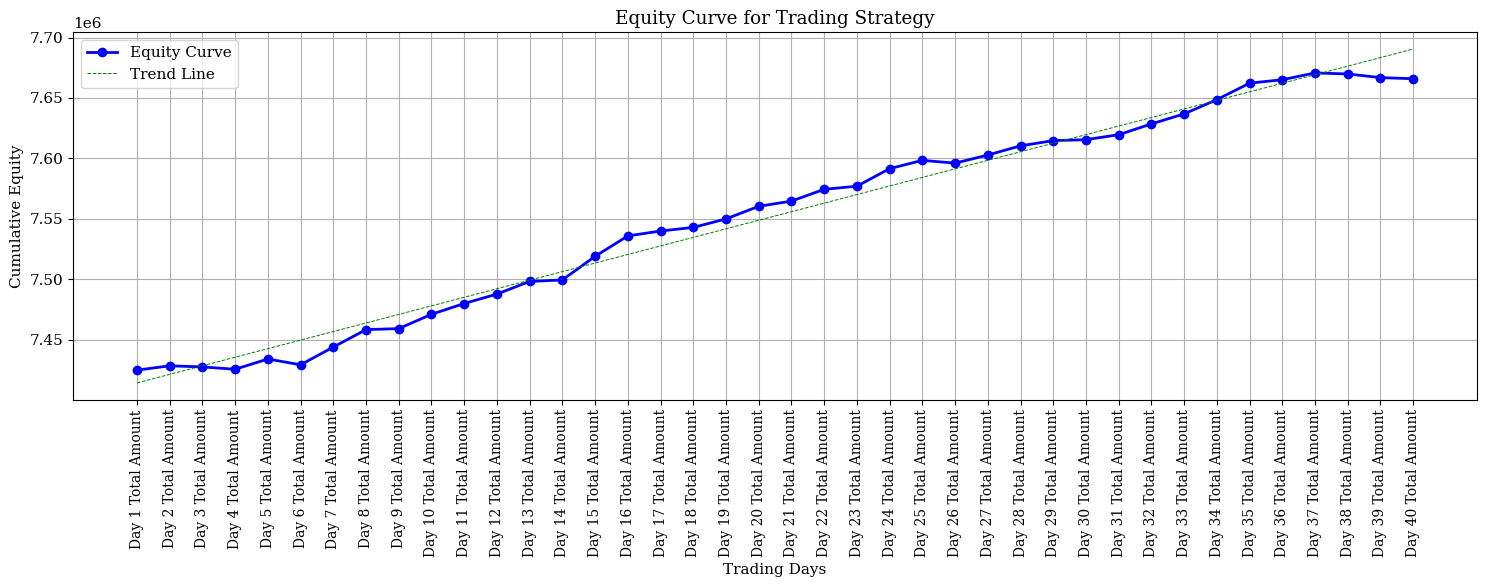

In [58]:
# PLOT THE EQUITY GRAPH

Final_result_df_plot = Final_result_df[['Symbol', 'Date', 'Breakout Date', 'Entry Date', 'Exit Date',
                                        'Day 1 Total Amount', 'Day 2 Total Amount', 'Day 3 Total Amount',
                                        'Day 4 Total Amount', 'Day 5 Total Amount', 'Day 6 Total Amount',
                                        'Day 7 Total Amount', 'Day 8 Total Amount', 'Day 9 Total Amount',
                                        'Day 10 Total Amount', 'Day 11 Total Amount', 'Day 12 Total Amount',
                                        'Day 13 Total Amount', 'Day 14 Total Amount', 'Day 15 Total Amount',
                                        'Day 16 Total Amount', 'Day 17 Total Amount', 'Day 18 Total Amount',
                                        'Day 19 Total Amount', 'Day 20 Total Amount', 'Day 21 Total Amount',
                                        'Day 22 Total Amount', 'Day 23 Total Amount', 'Day 24 Total Amount',
                                        'Day 25 Total Amount', 'Day 26 Total Amount', 'Day 27 Total Amount',
                                        'Day 28 Total Amount', 'Day 29 Total Amount', 'Day 30 Total Amount',
                                        'Day 31 Total Amount', 'Day 32 Total Amount', 'Day 33 Total Amount',
                                        'Day 34 Total Amount', 'Day 35 Total Amount', 'Day 36 Total Amount',
                                        'Day 37 Total Amount', 'Day 38 Total Amount', 'Day 39 Total Amount',
                                        'Day 40 Total Amount']]

equity_curve = Final_result_df_plot.sum()

# PLOTTING THE EQUITY CURVE
# Convert the data to numeric type, handling errors with 'coerce' to replace non-numeric values with NaN
equity_curve_numeric = pd.to_numeric(equity_curve[1:], errors='coerce')
equity_curve_numeric = equity_curve_numeric.dropna()

# Trend line
x_values = np.arange(len(equity_curve_numeric))
slope, intercept = np.polyfit(x_values, equity_curve_numeric, 1)

# PLOTTING THE EQUITY CURVE
plt.figure(figsize=(15, 6))
plt.plot(equity_curve.index[1:], equity_curve_numeric, marker='o', linestyle='-', color='blue', label='Equity Curve',linewidth=2)

# Adding a trend line
trend_line = slope * x_values + intercept
plt.plot(equity_curve.index[1:], trend_line, linestyle='--', color='green', label='Trend Line',linewidth=0.7)

plt.xlabel('Trading Days')
plt.ylabel('Cumulative Equity')
plt.title('Equity Curve for Trading Strategy')
plt.grid(True)
plt.xticks(rotation=90, fontsize=10)
plt.legend()  # Add legend to differentiate between Equity Curve and Trend Line
plt.tight_layout()
plt.show()

In [59]:
# INTRACTIVE EQUITY GRAPH USING PLOTLY EXPRESS

fig = px.line(x=equity_curve.index[1:], y=equity_curve[1:])
fig.update_traces(mode='lines+markers', marker=dict(size=7), line=dict(width=2.5, color='green'))

# Adding the faded straight line
start_point = (equity_curve.index[1], equity_curve.iloc[1])
end_point = (equity_curve.index[-1], equity_curve.iloc[-1])

fig.add_shape(
    type='line',
    x0=start_point[0], y0=start_point[1],
    x1=end_point[0], y1=end_point[1],
    line=dict(color='rgba(0, 0, 0, 0.2)', width=1)
                                                   )

# Create a Plotly figure
#fig = px.line(x=equity_curve.index[1:], y=equity_curve[1:])
#fig.update_traces(mode='lines+markers', marker=dict(size=7), line=dict(width=2.5, color='green'))

fig.update_layout(
    title='Equity Curve for Trading Strategy',
    xaxis_title='Trading Days',
    yaxis_title='Cumulative Equity',
    xaxis=dict(tickangle=-90),
    showlegend=False,
    width=1350,  # Set the width in pixels
    height=600
              )

fig.show()

In [60]:
# SAVING THE FILE

#df_final_updated.to_csv('/content/drive/MyDrive/WQU_Capstone/Trading_results_per_day.csv')

### CONVERTING THE NOTEBOOK INTO HTML

In [61]:
# %%shell
# jupyter nbconvert --to html /content/drive/MyDrive/Colab_Notebooks/WQU_Capstone_Final.ipynb